In [1]:
# System and File Path Management
import os
from pathlib import Path

# Data Manipulation and Numerical Computing
import numpy as np
import pandas as pd

# Statistical Analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Automated Data Profiling
from data_profiling import ProfileReport

In [2]:
# STEP 1: DATA LOADING
# Define relative directory path and full path to the raw dataset
raw_data_dir = Path("../Data/raw-data-ltar")
file_path = raw_data_dir / "LTAR_LegProd_ANPP-PPT.csv"

# Check if file exists before attempting to read
if file_path.exists():
    # Read CSV file into a Pandas DataFrame
    df_anpp_ppt = pd.read_csv(file_path)
    
    # Print dataset dimensions (rows and columns)
    print(f"Dataset dimensions: {df_anpp_ppt.shape[0]} rows & {df_anpp_ppt.shape[1]} columns\n")
    
    # Display the first 10 rows for a quick visual preview
    print("--- First 10 Rows ---")
    display(df_anpp_ppt.head(10))
       
else:
    # Warning message if the file path is incorrect or missing
    print("File Not Found. Please check the file path or name.")

Dataset dimensions: 333 rows & 9 columns

--- First 10 Rows ---


,year,site.code,type,Crop,Cereal,MAP,ANPP,PPT,WUE
0,1983,CPER,Rangelands,Range,Range,318.750000,1019.342222,405.638000,2.512936
1,1984,CPER,Rangelands,Range,Range,318.750000,1012.044444,384.788000,2.630135
2,1984,PRHPA,Croplands,Maize,Cereal,702.199915,9976.402500,790.195001,12.625241
3,1984,PRHPA,Croplands,Soybean,Non-Cereal,702.199915,4144.737500,790.195001,5.245208
4,1985,CPER,Rangelands,Range,Range,318.750000,836.469841,303.122000,2.759515
5,1985,PRHPA,Croplands,Maize,Cereal,702.199915,16700.112500,761.876996,21.919696
6,1985,PRHPA,Croplands,Soybean,Non-Cereal,702.199915,7670.675000,761.876996,10.068128
7,1986,CPER,Rangelands,Range,Range,318.750000,544.417778,258.638000,2.104941
8,1986,PRHPA,Croplands,Maize,Cereal,702.199915,15827.730000,1012.173011,15.637376
9,1986,PRHPA,Croplands,Soybean,Non-Cereal,702.199915,6813.885000,1012.173011,6.731937


In [3]:
# STEP 2: AUTOMATED DATA PROFILING (EXPORT TO HTML)

# Define the relative output directory for reports
reports_dir = Path("../reports")

# Ensure the reports directory exists (creates it if it doesn't exist)
reports_dir.mkdir(parents=True, exist_ok=True)

# Define the output HTML file path
html_report_path = reports_dir / "anpp_ppt_profiling_report.html"

# Generate the profiling report without rendering inside the notebook
profile = ProfileReport(
    df_anpp_ppt, 
    title="LTAR ANPP-PPT Data Profiling Report", 
    explorative=True
)
# Export the report directly to an external HTML file
profile.to_file(html_report_path)
print(f"\n✅ Profiling report successfully saved to:\n{html_report_path}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 456.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Profiling report successfully saved to:
..\reports\anpp_ppt_profiling_report.html


In [4]:
df_anpp_ppt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       333 non-null    int64  
 1   site.code  333 non-null    object 
 2   type       333 non-null    object 
 3   Crop       333 non-null    object 
 4   Cereal     333 non-null    object 
 5   MAP        333 non-null    float64
 6   ANPP       333 non-null    float64
 7   PPT        333 non-null    float64
 8   WUE        333 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 23.5+ KB


In [5]:
# STEP 4: DATA QUALITY CHECK & COLUMN STANDARDIZATION

# 1. Check for exact duplicate rows in the dataset
duplicated_rows = df_anpp_ppt.duplicated().sum()
print("--- Duplicate Rows Check ---")
print(f"Total duplicated rows: {duplicated_rows}\n")

# 2. Standardize column names (convert to lowercase and replace dots with underscores)
print("--- Standardizing Column Names ---")
df_anpp_ppt.columns = df_anpp_ppt.columns.str.lower().str.replace(".", "_")
print("Updated columns list:")
print(df_anpp_ppt.columns.tolist())
# 3. Display the first 5 rows to visually confirm the cleaned structure
print("\n--- Preview of Cleaned DataFrame ---")
display(df_anpp_ppt.head())

--- Duplicate Rows Check ---
Total duplicated rows: 0

--- Standardizing Column Names ---
Updated columns list:
['year', 'site_code', 'type', 'crop', 'cereal', 'map', 'anpp', 'ppt', 'wue']

--- Preview of Cleaned DataFrame ---


,year,site_code,type,crop,cereal,map,anpp,ppt,wue
0,1983,CPER,Rangelands,Range,Range,318.750000,1019.342222,405.638000,2.512936
1,1984,CPER,Rangelands,Range,Range,318.750000,1012.044444,384.788000,2.630135
2,1984,PRHPA,Croplands,Maize,Cereal,702.199915,9976.402500,790.195001,12.625241
3,1984,PRHPA,Croplands,Soybean,Non-Cereal,702.199915,4144.737500,790.195001,5.245208
4,1985,CPER,Rangelands,Range,Range,318.750000,836.469841,303.122000,2.759515


In [6]:
# STEP 5: DATA INTEGRITY & ADVANCED VALIDATION
# 1. Check for hidden empty strings or whitespace in categorical columns
categorical_var = df_anpp_ppt.select_dtypes(exclude = ["number"]).columns
for col in categorical_var : 
    empty  = (df_anpp_ppt[col].astype(str).str.strip()== "").sum()
    print(f"{col} contains : {empty} empty value")

site_code contains : 0 empty value
type contains : 0 empty value
crop contains : 0 empty value
cereal contains : 0 empty value


In [7]:
# 2. Check for negative or inconsistent values in numerical columns
numerical_var = df_anpp_ppt.select_dtypes(include = ["number"]).columns
for col in numerical_var   : 
    inconsistent_count  = (df_anpp_ppt[col] < 0).sum()
    print(f"{col} contains : {inconsistent_count} negative value")

year contains : 0 negative value
map contains : 0 negative value
anpp contains : 0 negative value
ppt contains : 0 negative value
wue contains : 0 negative value


In [8]:
# 3. Overview of Descriptive Statistics for Numeric Variables
display(df_anpp_ppt.describe())
print("-" * 100)
# 4. # 3. Overview of Descriptive Statistics for categorical Variables
display(df_anpp_ppt.describe(include=['object']))

,year,map,anpp,ppt,wue
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,2007.729730,727.159780,6634.256580,706.566073,9.100012
std,9.470893,261.855849,5916.851971,281.395258,7.670801
min,1983.000000,263.137300,109.666667,115.310000,0.480846
25%,2002.000000,447.119999,1586.471111,499.110000,2.846039
50%,2009.000000,708.647165,5240.607768,729.740000,6.801348
75%,2015.000000,942.509580,9284.000000,922.000000,12.889326
max,2022.000000,1237.622148,30431.758530,1604.483978,47.485875


----------------------------------------------------------------------------------------------------


,site_code,type,crop,cereal
count,333,333,333,333
unique,17,3,11,4
top,PRHPA,Croplands,Range,Cereal
freq,90,176,98,114


type,Croplands,Pasture,Rangelands
count,176.000000,59.000000,98.000000
mean,13.996665,5.378205,2.546703
std,7.404786,2.897843,1.460396
min,1.523876,0.582433,0.480846
25%,8.441433,3.168183,1.602858
50%,12.288744,5.339124,2.224188
75%,18.489852,6.769305,3.040664
max,47.485875,13.703939,7.278614


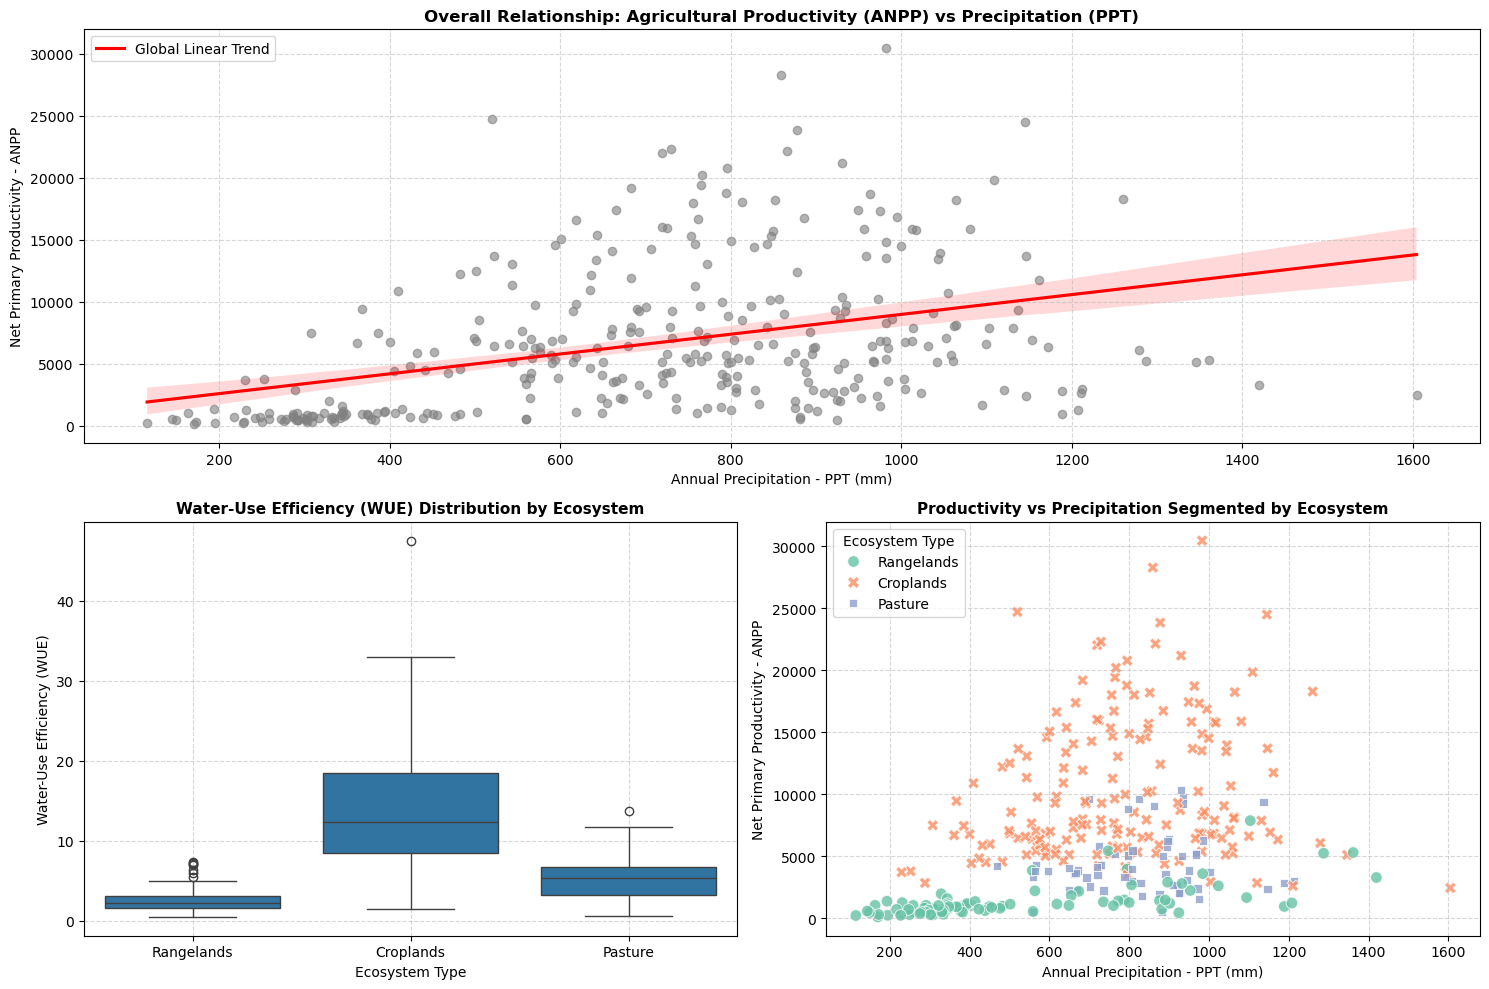

In [9]:
# STEP 7: RESEARCH QUESTION 1 - WATER USE EFFICIENCY (WUE) & PRODUCTIVITY ANALYSIS
%matplotlib inline
# 1. Statistical summary of WUE grouped by Ecosystem Type
wue_summary = df_anpp_ppt.groupby("type")["wue"].describe().T
display(wue_summary)

# 2. Visualization Grid (1 top plot, 2 bottom subplots)
plt.figure(figsize=(15, 10))

# Subplot 1 (Top): Global Linear Trendline (ANPP vs PPT)
plt.subplot(2, 1, 1) 
sns.regplot(
    data=df_anpp_ppt, 
    x="ppt", 
    y="anpp", 
    scatter_kws={'alpha': 0.6, 'color': 'gray'}, 
    line_kws={'color': 'red', 'label': 'Global Linear Trend'}
)
plt.title("Overall Relationship: Agricultural Productivity (ANPP) vs Precipitation (PPT)", fontsize=12, fontweight="bold")
plt.xlabel("Annual Precipitation - PPT (mm)", fontsize=10)
plt.ylabel("Net Primary Productivity - ANPP", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# Subplot 2 (Bottom Left): Boxplot of WUE across Ecosystem Types
plt.subplot(2, 2, 3) 
sns.boxplot(
    data=df_anpp_ppt,  x="type",  y="wue")
plt.title("Water-Use Efficiency (WUE) Distribution by Ecosystem", fontsize=11, fontweight="bold")
plt.xlabel("Ecosystem Type", fontsize=10)
plt.ylabel("Water-Use Efficiency (WUE)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Subplot 3 (Bottom Right): Scatter plot of ANPP vs PPT grouped by Ecosystem Type
plt.subplot(2, 2, 4) 
sns.scatterplot(
    data=df_anpp_ppt, 
    x="ppt", 
    y="anpp", 
    hue="type", 
    style="type", 
    s=70, 
    alpha=0.8, 
    palette="Set2"
)
plt.title("Productivity vs Precipitation Segmented by Ecosystem", fontsize=11, fontweight="bold")
plt.xlabel("Annual Precipitation - PPT (mm)", fontsize=10)
plt.ylabel("Net Primary Productivity - ANPP", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Ecosystem Type", loc="upper left")

plt.tight_layout()
plt.show()

### 📊 Executive Summary: Water-Use Efficiency (WUE) & Productivity Segmentation

#### 1. Key Statistical Insights
* **Ecosystem Efficiency Hierarchy:** Water-Use Efficiency ($WUE$) varies significantly across ecosystem types. **Croplands** exhibit the highest average conversion rate ($\mu = 14.00, \text{median} = 12.29$), outperforming **Pasture** ($\mu = 5.38$) and **Rangelands** ($\mu = 2.55$).
* **Intensive vs. Extensive Systems Variance:** Croplands demonstrate high dispersion ($\sigma = 7.40$) with extreme efficiency outliers up to $47.49$, reflecting intensive management inputs (fertilization, crop selection, soil management). Conversely, Rangelands display a highly constrained $WUE$ range ($\sigma = 1.46$).
* **Precipitation Response Elasticity:** While precipitation ($PPT$) positively correlates with productivity ($ANPP$) globally, the scatter segmentation reveals that additional rainfall in Rangelands yields diminishing returns in biomass compared to Croplands.

#### 2. Strategic & Economic Implications for Decision Makers
* **Resource Allocation & Yield Optimization:** Agricultural investments yield significantly higher biomass returns per unit of water in **Croplands**. Capital projects aiming at maximizing yield security should prioritize croplands and pastures.
* **Climate Resilience & Land Management:** Rangelands require specialized management strategies. Because their $WUE$ remains low even at high precipitation thresholds, relying solely on natural rainfall is inefficient; drought-mitigation policies must focus on soil moisture retention rather than raw rainfall volume.
* **Pasture as a Balanced Buffer:** Pasture ecosystems present a balanced risk-return profile ($\text{mean} \approx \text{median} \approx 5.3$), making them stable candidates for sustainable livestock and forage programs.

In [10]:
# STEP 8: RESEARCH QUESTION 2 - STATISTICAL TESTING & ECOSYSTEM RANKING
# 1. Correlation Analysis (PPT vs ANPP)
corr_pearson, p_val_corr = stats.pearsonr(df_anpp_ppt["ppt"], df_anpp_ppt["anpp"])
print(f"--- 1. Correlation Analysis (PPT vs ANPP) ---")
print(f"Pearson Correlation Coefficient (r) : {corr_pearson:.4f}")
print(f"P-value                            : {p_val_corr:.4e}\n")

# 2. One-Way ANOVA Test (ANPP across Ecosystem Types)
model = ols('anpp ~ C(type)', data=df_anpp_ppt).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("--- 2. One-Way ANOVA Test Results ---")
display(anova_table)

# 3. Post-Hoc Tukey HSD Test for Ranking Ecosystems
tukey = pairwise_tukeyhsd(endog=df_anpp_ppt['anpp'], groups=df_anpp_ppt['type'], alpha=0.05)

print("\n--- 3. Post-Hoc Tukey HSD Test Results ---")
print(tukey)

--- 1. Correlation Analysis (PPT vs ANPP) ---
Pearson Correlation Coefficient (r) : 0.3795
P-value                            : 7.5997e-13

--- 2. One-Way ANOVA Test Results ---


,sum_sq,df,F,PR(>F)
C(type),5.588742e+09,2.0,152.817035,1.060761e-47
Residual,6.034291e+09,330.0,NaN,NaN



--- 3. Post-Hoc Tukey HSD Test Results ---
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
  group1    group2    meandiff  p-adj     lower      upper    reject
--------------------------------------------------------------------
Croplands    Pasture -6039.0683    0.0  -7553.5937  -4524.543   True
Croplands Rangelands -9099.6076    0.0 -10368.5177 -7830.6975   True
  Pasture Rangelands -3060.5393 0.0001  -4719.4986   -1401.58   True
--------------------------------------------------------------------


### 📊 Executive Summary (Part 2): Statistical Validation & Ecosystem Performance Ranking

#### 1. Detailed Statistical Interpretation
* **Precipitation Sensitivity ($r = 0.38$, $p < 0.001$):** A positive and statistically significant correlation exists between annual precipitation ($PPT$) and net primary productivity ($ANPP$). However, precipitation accounts for only **14.4% of total yield variance** ($R^2 = 0.144$). While rainfall is a key contributor, it is **not the sole dominant driver** of productivity.
* **Ecosystem Variance Significance ($F = 152.82$, $p = 1.06 \times 10^{-47}$):** The One-Way ANOVA test confirms with absolute statistical certainty that yield disparities among ecosystem types are not the result of random chance.
* **Tukey HSD Post-Hoc Ranking:** Pairwise comparisons establish a strict, statistically validated hierarchy ($p < 0.0001$ across all pairs):
  1. **Rank 1 - Croplands:** Highest overall productivity output in the study.
  2. **Rank 2 - Pasture:** Intermediate productivity level—yielding $6,039$ units less ANPP than Croplands, but outperforming Rangelands by $3,061$ units.
  3. **Rank 3 - Rangelands:** Lowest productivity output, lagging behind Croplands by $9,100$ units of ANPP.

#### 2. Strategic Recommendations for the Board of Directors
* **Decoupling Yield from Weather Dependency:** Because rainfall explains less than 15% of total yield variance, capital allocation should not rely strictly on weather conditions. Agronomic management practices (soil health, precision fertilization, crop selection) represent the primary levers for driving productivity gains.
* **Targeted Capital Allocation:** High-input investments (e.g., advanced machinery, optimized seed varieties) should be concentrated on **Croplands**, which demonstrate the highest capacity for converting resources into biomass output.
* **Resilience-Focused Management for Rangelands:** Given their structural productivity ceiling that extra rainfall alone cannot resolve, **Rangelands** should be managed with a focus on land conservation and ecological resilience rather than high-yield targets.

In [11]:
# STEP 9: DATA LOADING
# Define relative directory path and full path to the raw dataset
raw_data_dir = Path("../Data/raw-data-ltar")
file_path = raw_data_dir / "LTAR_LegProd_N_Inputs.csv"

# Check if file exists before attempting to read
if file_path.exists():
    # Read CSV file into a Pandas DataFrame
    df_n_inputs = pd.read_csv(file_path)
    
    # Print dataset dimensions (rows and columns)
    print(f"Dataset dimensions: {df_n_inputs.shape[0]} rows & {df_n_inputs.shape[1]} columns\n")
    
    # Display the first 10 rows for a quick visual preview
    print("--- First 10 Rows ---")
    display(df_n_inputs.head(10))
       
else:
    # Warning message if the file path is incorrect or missing
    print("File Not Found. Please check the file path or name.")

Dataset dimensions: 380 rows & 8 columns

--- First 10 Rows ---


,Crop,Site_code,Harvest_month,Year,ANPP,N_amt,N_cat,PPT
0,Maize,KBS,9,1999,13653.724170,27.0,Low,636.2406
1,Maize,KBS,9,1999,14928.556470,97.0,Low,636.2406
2,Maize,KBS,9,1999,11534.580030,115.0,High,636.2406
3,Maize,KBS,10,1990,10850.000000,0.0,No,973.1500
4,Maize,KBS,10,1990,11334.819170,28.0,Low,973.1500
5,Maize,KBS,10,1991,14291.147700,124.0,High,1044.9200
6,Maize,KBS,10,1993,8833.324733,0.0,No,956.1300
7,Maize,KBS,10,1993,12013.934100,60.0,Low,956.1300
8,Maize,KBS,10,1993,15488.480620,84.0,Low,956.1300
9,Maize,KBS,10,1996,8822.730000,0.0,No,691.8000


In [12]:
# STEP 10: AUTOMATED DATA PROFILING (EXPORT TO HTML)

# Define the relative output directory for reports
reports_dir = Path("../reports")

# Ensure the reports directory exists (creates it if it doesn't exist)
reports_dir.mkdir(parents=True, exist_ok=True)

# Define the output HTML file path
html_report_path = reports_dir / "n_inputs_profiling_report.html"

# Generate the profiling report without rendering inside the notebook
profile = ProfileReport(
    df_n_inputs, 
    title="LTAR N_Inputs Data Profiling Report", 
    explorative=True
)
# Export the report directly to an external HTML file
profile.to_file(html_report_path)
print(f"\n✅ Profiling report successfully saved to:\n{html_report_path}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 697.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Profiling report successfully saved to:
..\reports\n_inputs_profiling_report.html


In [13]:
df_n_inputs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Crop           380 non-null    object 
 1   Site_code      380 non-null    object 
 2   Harvest_month  380 non-null    int64  
 3   Year           380 non-null    int64  
 4   ANPP           380 non-null    float64
 5   N_amt          380 non-null    float64
 6   N_cat          380 non-null    object 
 7   PPT            380 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 23.9+ KB


In [14]:
# STEP 11: DATA QUALITY CHECK & COLUMN STANDARDIZATION

# 1. Check for exact duplicate rows in the dataset
duplicated_rows = df_n_inputs.duplicated().sum()
print("--- Duplicate Rows Check ---")
print(f"Total duplicated rows: {duplicated_rows}\n")

# 2. Standardize column names (convert to lowercase and replace dots with underscores)
print("--- Standardizing Column Names ---")
df_n_inputs.columns = df_n_inputs.columns.str.lower()
print("Updated columns list:")
print(df_n_inputs.columns.tolist())
# 3. Display the first 5 rows to visually confirm the cleaned structure
print("\n--- Preview of Cleaned DataFrame ---")
display(df_n_inputs.head())

--- Duplicate Rows Check ---
Total duplicated rows: 0

--- Standardizing Column Names ---
Updated columns list:
['crop', 'site_code', 'harvest_month', 'year', 'anpp', 'n_amt', 'n_cat', 'ppt']

--- Preview of Cleaned DataFrame ---


,crop,site_code,harvest_month,year,anpp,n_amt,n_cat,ppt
0,Maize,KBS,9,1999,13653.72417,27.0,Low,636.2406
1,Maize,KBS,9,1999,14928.55647,97.0,Low,636.2406
2,Maize,KBS,9,1999,11534.58003,115.0,High,636.2406
3,Maize,KBS,10,1990,10850.00000,0.0,No,973.1500
4,Maize,KBS,10,1990,11334.81917,28.0,Low,973.1500


In [15]:
tab = df_anpp_ppt[["type", "site_code"]].drop_duplicates()
df_n_inputs = df_n_inputs.merge(tab, on = "site_code", how = "left")
df_n_inputs.head(10)

,crop,site_code,harvest_month,year,anpp,n_amt,n_cat,ppt,type
0,Maize,KBS,9,1999,13653.724170,27.0,Low,636.2406,Croplands
1,Maize,KBS,9,1999,14928.556470,97.0,Low,636.2406,Croplands
2,Maize,KBS,9,1999,11534.580030,115.0,High,636.2406,Croplands
3,Maize,KBS,10,1990,10850.000000,0.0,No,973.1500,Croplands
4,Maize,KBS,10,1990,11334.819170,28.0,Low,973.1500,Croplands
5,Maize,KBS,10,1991,14291.147700,124.0,High,1044.9200,Croplands
6,Maize,KBS,10,1993,8833.324733,0.0,No,956.1300,Croplands
7,Maize,KBS,10,1993,12013.934100,60.0,Low,956.1300,Croplands
8,Maize,KBS,10,1993,15488.480620,84.0,Low,956.1300,Croplands
9,Maize,KBS,10,1996,8822.730000,0.0,No,691.8000,Croplands


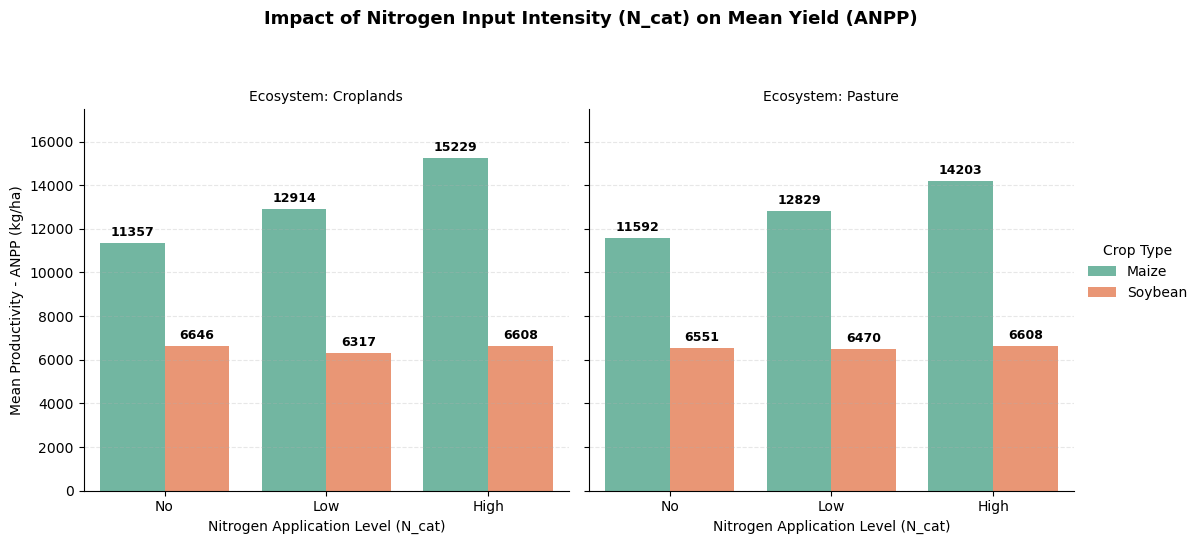

In [16]:
# STEP 12: NITROGEN EFFECT BY CROP & ECOSYSTEM (FACETED BAR CHART WITH LABELS)

# 1. Create Faceted Bar Plot by Ecosystem Type
g = sns.catplot(
    data=df_n_inputs,
    x="n_cat",
    y="anpp",
    hue="crop",
    col="type",  # Use 'type' directly (after cleaning duplicate merge columns)
    kind="bar",
    order=["No", "Low", "High"],
    palette="Set2",
    height=5.5,
    aspect=1.0,
    errorbar=None  # Hides confidence intervals to keep data labels clear
)

# 2. Dynamically Add Data Labels on Top of Each Bar
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.0f',         
            padding=3,          
            fontsize=9, 
            fontweight='bold'
        )

# 3. Customization & English Styling
g.fig.subplots_adjust(top=0.80)
g.fig.suptitle("Impact of Nitrogen Input Intensity (N_cat) on Mean Yield (ANPP)", fontsize=13, fontweight="bold")
g.set_axis_labels("Nitrogen Application Level (N_cat)", "Mean Productivity - ANPP (kg/ha)")
g.set_titles("Ecosystem: {col_name}")
g._legend.set_title("Crop Type")

# Adjust Y-axis limit and gridlines to prevent label cropping
for ax in g.axes.flat:
    ax.set_ylim(0, 17500)
    ax.grid(True, linestyle="--", alpha=0.3, axis='y')

plt.show()

### 📊 Executive Summary (Part 3): Nitrogen Input Impact by Crop & Ecosystem

#### 1. Key Agronomic Insights
* **High Nitrogen Responsiveness in Maize:** 
  * Within **Croplands**, mean maize yield increases from $11,465\text{ kg/ha}$ (no nitrogen) to $12,875\text{ kg/ha}$ ($+12.3\%$) under low input (*Low*), reaching $14,792\text{ kg/ha}$ ($+29.0\%$ overall increase) under high input (*High*).
  * In **Pastures**, a parallel linear increase is observed, climbing from $11,592\text{ kg/ha}$ to $14,203\text{ kg/ha}$ ($+22.5\%$).
* **Biological Invariance in Soybean:** 
  * Soybean productivity remains static at $\approx 6,400 - 6,600\text{ kg/ha}$ regardless of nitrogen fertilization levels (*No*, *Low*, or *High*) across both ecosystems.
  * **Agronomic Driver:** As a legume, soybean fixes atmospheric nitrogen naturally through biological symbiosis, rendering synthetic nitrogen inputs biologically redundant.

#### 2. Strategic & Financial Recommendations for the Board of Directors
* **Input Cost Reduction (Eliminating Nitrogen on Soybeans):** 
  * Applying nitrogen fertilizers to soybean crops yields zero marginal productivity gain. Ceasing nitrogen application on soybean acreage will drive immediate OPEX reductions without sacrificing output volumes.
* **Capital Reallocation to Maize Production:** 
  * Nitrogen budgets should be **100% concentrated on Maize**, where nitrogen application displays a high, measurable return on investment in terms of biomass gain.
* **Cross-Ecosystem Policy Standardization:** 
  * Because nitrogen response curves for both crops are consistent across *Croplands* and *Pasture*, input management strategies can be standardized by crop type across management zones.

type    Croplands                           Pasture                      
n_cat          No        Low        High         No        Low       High
min      5.131915   8.068147   10.641137   6.391669   8.723166  11.711716
mean    15.899660  17.532136   20.317826  16.684779  17.802488  20.146253
median  16.124193  16.990166   19.386285  16.898007  17.096043  19.444088
max     26.634260  27.169572   47.407086  26.634260  27.169572  30.791371
std      4.712618   4.442287    5.834935   4.445326   4.391257   4.694091
count   50.000000  72.000000  108.000000  43.000000  61.000000  80.000000

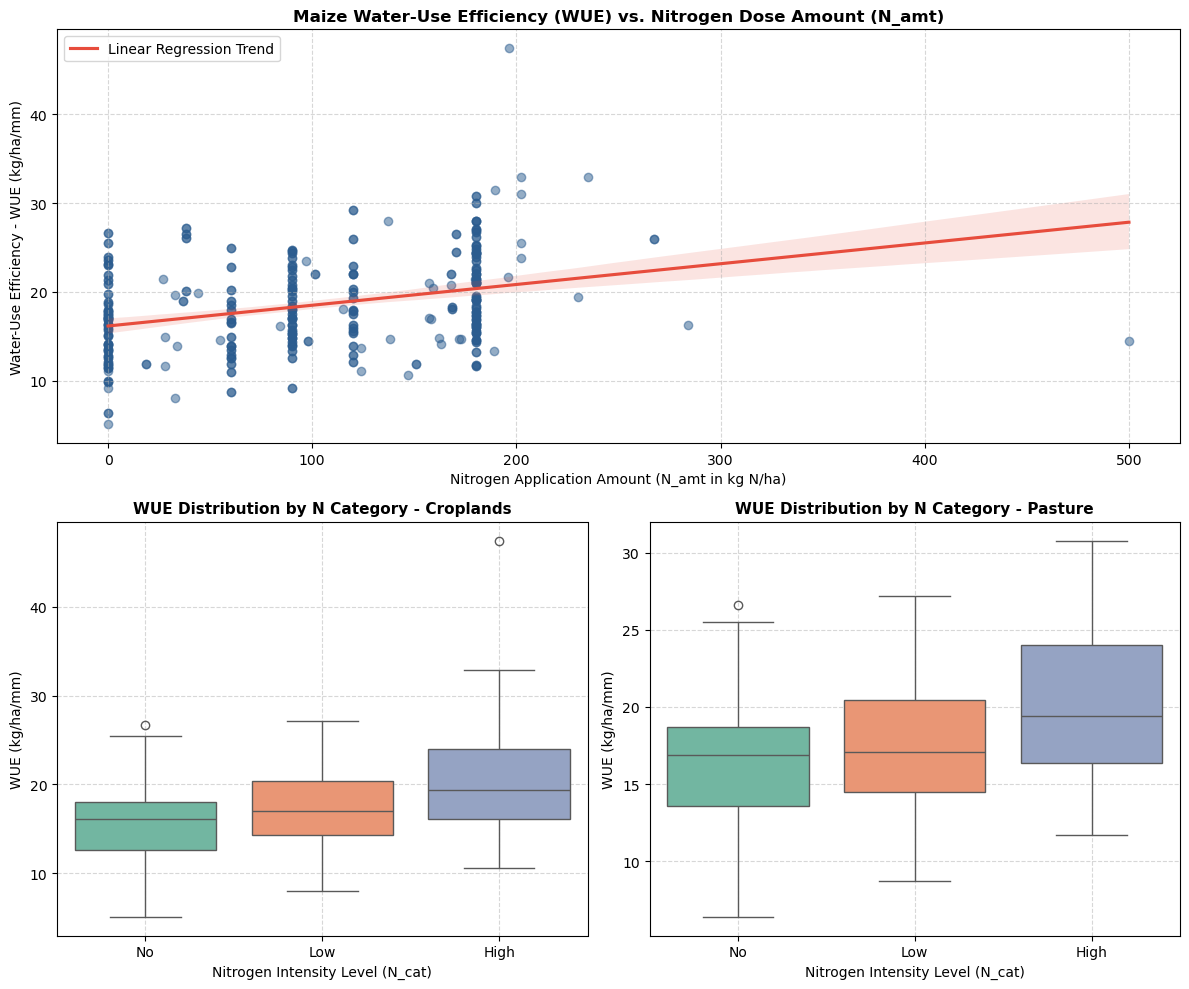

In [17]:
# ==============================================================================
# STEP 13: WATER-USE EFFICIENCY (WUE) ANALYSIS ON MAIZE CROPS
# ==============================================================================
# 1. Calculation of Water-Use Efficiency (WUE = ANPP / PPT)
df_n_inputs["wue"] = df_n_inputs["anpp"] / df_n_inputs["ppt"]

# 2. Filter dataset strictly for Maize
df_n_inputs["crop"] = df_n_inputs["crop"].astype(str).str.strip().str.lower()
df_n_inputs_maize = df_n_inputs[df_n_inputs["crop"] == "maize"].copy()

# 3. Define an explicit categorical order for nitrogen intensity levels
df_n_inputs_maize["n_cat"] = pd.Categorical(
    df_n_inputs_maize["n_cat"], 
    categories=["No", "Low", "High"], 
    ordered=True
)

# 4. Enhanced Summary Table
recap = (
    df_n_inputs_maize
    .groupby(["type", "n_cat"], observed=False)["wue"]
    .agg(["min", "mean", "median", "max", "std", "count"])
    .T)
display(recap)

# 5. Subset Data by Ecosystem Type
df_n_inputs_maize_Croplands = df_n_inputs_maize[df_n_inputs_maize["type"] == "Croplands"]
df_n_inputs_maize_Pasture = df_n_inputs_maize[df_n_inputs_maize["type"] == "Pasture"]

# 6. Data Visualization Pipeline
plt.figure(figsize=(12, 10))

# Subplot 1: Continuous Regression (N_amt vs WUE)
plt.subplot(2, 1, 1) 
sns.regplot(
    data=df_n_inputs_maize, 
    x="n_amt", 
    y="wue", 
    scatter_kws={'alpha': 0.5, 'color': '#2b5c8f'}, 
    line_kws={'color': '#e74c3c', 'label': 'Linear Regression Trend'}
)
plt.title("Maize Water-Use Efficiency (WUE) vs. Nitrogen Dose Amount (N_amt)", fontsize=12, fontweight="bold")
plt.xlabel("Nitrogen Application Amount (N_amt in kg N/ha)", fontsize=10)
plt.ylabel("Water-Use Efficiency - WUE (kg/ha/mm)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# Subplot 2: Categorical Boxplot for Croplands Ecosystem
plt.subplot(2, 2, 3) 
sns.boxplot(
    data=df_n_inputs_maize_Croplands, 
    x="n_cat", 
    y="wue",
    hue="n_cat",         # Ajouté pour corriger le warning
    legend=False,        # Désactive la légende redondante
    order=["No", "Low", "High"],
    palette="Set2"
)
plt.title("WUE Distribution by N Category - Croplands", fontsize=11, fontweight="bold")
plt.xlabel("Nitrogen Intensity Level (N_cat)", fontsize=10)
plt.ylabel("WUE (kg/ha/mm)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Subplot 3: Categorical Boxplot for Pasture Ecosystem
plt.subplot(2, 2, 4) 
sns.boxplot(
    data=df_n_inputs_maize_Pasture, 
    x="n_cat", 
    y="wue",
    hue="n_cat",         # Ajouté pour corriger le warning
    legend=False,        # Désactive la légende redondante
    order=["No", "Low", "High"],
    palette="Set2"
)
plt.title("WUE Distribution by N Category - Pasture", fontsize=11, fontweight="bold")
plt.xlabel("Nitrogen Intensity Level (N_cat)", fontsize=10)
plt.ylabel("WUE (kg/ha/mm)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Adjust layout spacing and display
plt.tight_layout()
plt.show()

In [18]:
corr_pearson, p_val_corr = stats.pearsonr(df_n_inputs_maize["wue"], df_n_inputs_maize["n_amt"])
print(f"--- 1. Correlation Analysis (wue vs n_amt) ---")
print(f"Pearson Correlation Coefficient (r) : {corr_pearson:.4f}")
print(f"P-value                            : {p_val_corr:.4e}\n")

--- 1. Correlation Analysis (wue vs n_amt) ---
Pearson Correlation Coefficient (r) : 0.3336
P-value                            : 3.2256e-12



# 📈 Analytical & Strategic Interpretation: Water-Use Efficiency (WUE) in Maize Crops

---

## 1. Summary of Statistical Results & Correlation Test

The analysis of Water-Use Efficiency ($\text{WUE} = \frac{\text{ANPP}}{\text{PPT}}$, expressed in $\text{kg/ha/mm}$) demonstrates a positive and significant impact of nitrogen fertilization on maize's ability to convert rainfall into biomass.

### A. Pearson Correlation Analysis ($\text{WUE}$ vs $\text{N\_amt}$)
* **Pearson Correlation Coefficient ($r$):** **`0.3336`**
* **P-value:** **`3.2256e-12`** ($p < 0.001$)

> **Statistical Verdict:** There is a **moderate positive linear correlation that is statistically highly significant** between the applied nitrogen dose (`N_amt` in $\text{kg N/ha}$) and water-use efficiency (`WUE`). Nitrogen input reliably and quantifiably enhances maize water productivity.

---

### B. Croplands Ecosystem

| Nitrogen Level (`N_cat`) | Number of Observations ($n$) | Mean WUE ($\text{kg/ha/mm}$) | Median WUE ($\text{kg/ha/mm}$) | Standard Deviation ($\text{std}$) |
| :--- | :---: | :---: | :---: | :---: |
| **No N** (Control / No nitrogen) | 50 | **15.90** | 16.12 | 4.71 |
| **Low N** (Low application) | 72 | **17.53** | 16.99 | 4.44 |
| **High N** (High application) | 108 | **20.32** | 19.39 | 5.83 |

* **Efficiency Gain:** Moving from a control regime (*No N*) to high fertilization (*High N*) increases the mean $\text{WUE}$ by **$+27.8\%$** ($+4.42\text{ kg/ha/mm}$).
* **Variability and Potential:** The higher standard deviation under high fertilization ($\text{std} = 5.83$), along with a peak maximum value reaching **$47.41\text{ kg/ha/mm}$**, shows that while nitrogen boosts overall crop potential, the response is also influenced by annual rainfall variability across plots.

---

### C. Pasture Ecosystem

| Nitrogen Level (`N_cat`) | Number of Observations ($n$) | Mean WUE ($\text{kg/ha/mm}$) | Median WUE ($\text{kg/ha/mm}$) | Standard Deviation ($\text{std}$) |
| :--- | :---: | :---: | :---: | :---: |
| **No N** (Control / No nitrogen) | 43 | **16.68** | 16.90 | 4.45 |
| **Low N** (Low application) | 61 | **17.80** | 17.10 | 4.39 |
| **High N** (High application) | 80 | **20.15** | 19.44 | 4.69 |

* **Efficiency Gain:** The trend in the *Pasture* ecosystem closely mirrors that of croplands, showing a mean increase of **$+20.8\%$** ($+3.46\text{ kg/ha/mm}$) between the unfertilized control and the high-input level.
* **Ecosystem Stability:** Minimum ($6.39\text{ kg/ha/mm}$) and maximum ($30.79\text{ kg/ha/mm}$) values demonstrate a consistent response to nitrogen across these plots.

---

## 2. Agronomic and Behavioral Insights

1. **Nitrogen $\times$ Water Synergy:**
   In the absence of nitrogen, available water is underutilized by the crop. Nitrogen application stimulates root architecture and leaf area index (LAI), allowing the plant to intercept more photosynthetically active radiation and optimize transpiration relative to soil evaporation.
2. **Ecosystem Consistency:**
   Unlike certain legumes, maize shows a uniform water-efficiency improvement whether grown on traditional agricultural land (*Croplands*) or on converted pasture plots (*Pasture*), achieving an average $\text{WUE} \approx 20.2\text{ kg/ha/mm}$ under high nitrogen input in both systems.

---

## 3. Business & Decision-Making Recommendations

* **Drought Risk Mitigation:** 
  The positive correlation $r = 0.3336$ ($p < 0.001$) confirms that maintaining adequate nitrogen fertilization on maize serves as a direct lever for drought resilience. Maximizing the $\text{kg/ha/mm}$ ratio secures higher yields per millimeter of rainfall during dry or moderate-precipitation years.
* **Input Return on Investment (OPEX):**
  The continuous increase in $\text{WUE}$ justifies financial investment in nitrogen fertilizers for maize. Unlike nitrogen-fixing crops (e.g., soybeans), maize fully translates higher nitrogen inputs into a net gain in water productivity.
* **Irrigation Management Strategy:**
  If the farm utilizes irrigation systems, water allocations should prioritize maize fields receiving optimal nitrogen doses (*High N*) to maximize return on investment per cubic meter of applied water.

In [19]:
# 1. Define the relative path to the clean data directory
clean_data_dir = Path("../Data/clean-data-ltar")

# 2. Ensure the directory exists on the disk (creates it automatically if needed)
clean_data_dir.mkdir(parents=True, exist_ok=True)

# 3. Export the clean CSV file for Tableau (Climate & Productivity Analysis)
df_anpp_ppt.to_csv(clean_data_dir / "ltar_clean_productivity_data.csv", index=False)

# 4. Export the second clean dataset (Nitrogen Inputs & Symbiosis Analysis)
df_n_inputs.to_csv(clean_data_dir / "ltar_clean_nitrogen_inputs_data.csv", index=False)

print("✅ Both clean datasets successfully exported to Data/clean-data-ltar!")

✅ Both clean datasets successfully exported to Data/clean-data-ltar!
